In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
def load_and_process_data(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    records = []
    analysis_scores_list = []
    feedback_scores_list = []
    
    for item in data:
        student_id = item['student_id']
        
        # Lấy accuracy tổng
        analysis_acc = item['analysis_eval']['accuracy']
        feedback_acc = item['feedback_eval']['accuracy']
        
        # Lấy mảng YES/NO để phân tích chi tiết từng tiêu chí (DQ)
        analysis_scores = item['analysis_eval']['scores']
        feedback_scores = item['feedback_eval']['scores']
        
        records.append({
            'student_id': student_id,
            'analysis_accuracy': analysis_acc,
            'feedback_accuracy': feedback_acc
        })
        
        analysis_scores_list.append(analysis_scores)
        feedback_scores_list.append(feedback_scores)
        
    df = pd.DataFrame(records)
    df_analysis_criteria = pd.DataFrame(analysis_scores_list)
    df_feedback_criteria = pd.DataFrame(feedback_scores_list)
    
    return df, df_analysis_criteria, df_feedback_criteria

# Tải dữ liệu (giả sử đọc file mốc 20%)
file_path_20 = 'evaluation_results_20full_f.json'
df_20, df_ana_20, df_feed_20 = load_and_process_data(file_path_20)

# ==========================================
# 2. PHÂN TÍCH ĐỊNH LƯỢNG (BẢNG 4.6)
# ==========================================
print("--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG (MỐC 20%) ---")
metrics = ['analysis_accuracy', 'feedback_accuracy']
for metric in metrics:
    mean_val = df_20[metric].mean() * 100
    min_val = df_20[metric].min()
    max_val = df_20[metric].max()
    std_val = df_20[metric].std()
    print(f"- {metric}: Trung bình = {mean_val:.2f}% | Biến thiên = [{min_val:.2f} - {max_val:.2f}] | Độ lệch chuẩn = {std_val:.4f}")

# ==========================================
# 3. TRÍCH XUẤT CASE STUDY (MỤC 4.4.3)
# ==========================================
print("\n--- NGHIÊN CỨU TRƯỜNG HỢP ĐIỂN HÌNH ---")
target_student_id = 538069
case_study = df_20[df_20['student_id'] == target_student_id]

if not case_study.empty:
    print(f"Sinh viên ID: {target_student_id}")
    print(f"Điểm đánh giá Analysis (Phân tích): {case_study['analysis_accuracy'].values[0]}")
    print(f"Điểm đánh giá Feedback (Phản hồi): {case_study['feedback_accuracy'].values[0]:.4f}")
    
    # Lấy chi tiết YES/NO của sinh viên này
    student_idx = case_study.index[0]
    print("Chi tiết các tiêu chí Analysis:", df_ana_20.iloc[student_idx].tolist())
    print("Chi tiết các tiêu chí Feedback:", df_feed_20.iloc[student_idx].tolist())
else:
    print(f"Không tìm thấy sinh viên ID {target_student_id} trong tập dữ liệu.")

--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG (MỐC 20%) ---
- analysis_accuracy: Trung bình = 89.17% | Biến thiên = [0.50 - 1.00] | Độ lệch chuẩn = 0.2043
- feedback_accuracy: Trung bình = 78.52% | Biến thiên = [0.56 - 1.00] | Độ lệch chuẩn = 0.1165

--- NGHIÊN CỨU TRƯỜNG HỢP ĐIỂN HÌNH ---
Sinh viên ID: 538069
Điểm đánh giá Analysis (Phân tích): 1.0
Điểm đánh giá Feedback (Phản hồi): 0.8889
Chi tiết các tiêu chí Analysis: ['YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES']
Chi tiết các tiêu chí Feedback: ['YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'NO', 'YES', 'YES']


/tmp/ipykernel_10048/3611267349.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Analysis (Phân tích)', 'Feedback (Phản hồi)'])
/tmp/ipykernel_10048/3611267349.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_feed_numeric = df_feed_20.applymap(lambda x: 1 if x == 'YES' else 0)


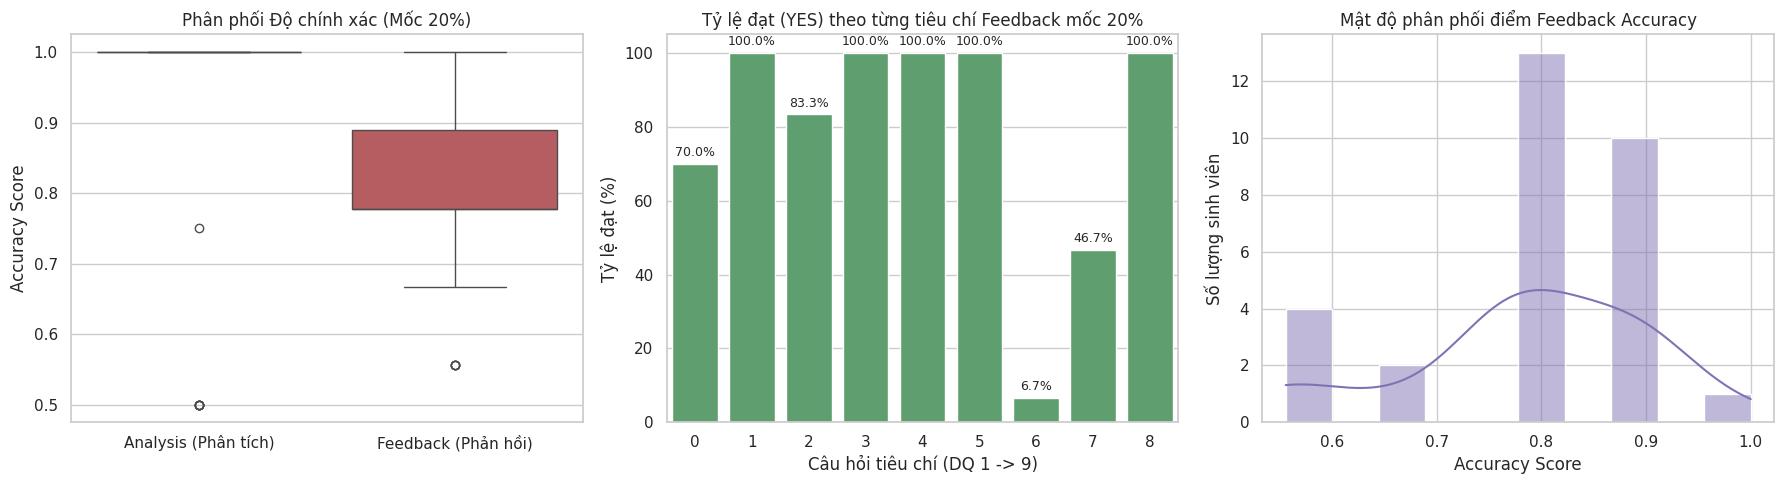

In [3]:
# Cài đặt phông chữ và style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# BIỂU ĐỒ 1: Boxplot thể hiện phân phối Accuracy của 2 giai đoạn
# Giúp thấy rõ độ biến thiên (0.5 - 1.0) của Feedback so với độ ổn định (1.0) của Analysis
# ---------------------------------------------------------
sns.boxplot(data=df_20[['analysis_accuracy', 'feedback_accuracy']], 
            palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Phân phối Độ chính xác (Mốc 20%)')
axes[0].set_xticklabels(['Analysis (Phân tích)', 'Feedback (Phản hồi)'])
axes[0].set_ylabel('Accuracy Score')

# ---------------------------------------------------------
# BIỂU ĐỒ 2: Bar chart thể hiện Tỷ lệ "YES" cho từng tiêu chí Feedback
# Giúp xác định chính xác điểm yếu của LLM khi sinh phản hồi
# ---------------------------------------------------------
# Chuyển YES thành 1, NO thành 0
df_feed_numeric = df_feed_20.applymap(lambda x: 1 if x == 'YES' else 0)
pass_rates = df_feed_numeric.mean() * 100

sns.barplot(x=pass_rates.index, y=pass_rates.values, color='#55A868', ax=axes[1])
axes[1].set_title('Tỷ lệ đạt (YES) theo từng tiêu chí Feedback mốc 20%')
axes[1].set_xlabel('Câu hỏi tiêu chí (DQ 1 -> 9)')
axes[1].set_ylabel('Tỷ lệ đạt (%)')
axes[1].set_ylim(0, 105)

# Thêm giá trị % lên trên mỗi cột
for i, v in enumerate(pass_rates.values):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=9)

# ---------------------------------------------------------
# BIỂU ĐỒ 3: Histogram thể hiện tần suất các nhóm điểm Feedback
# Trực quan hóa xem phần lớn các sinh viên rơi vào nhóm điểm nào
# ---------------------------------------------------------
sns.histplot(df_20['feedback_accuracy'], bins=10, kde=True, color='#8172B3', ax=axes[2])
axes[2].set_title('Mật độ phân phối điểm Feedback Accuracy')
axes[2].set_xlabel('Accuracy Score')
axes[2].set_ylabel('Số lượng sinh viên')

plt.tight_layout()
plt.show()